# MZM MLP PINN — Hyperparameter Tuning

## Overview
This notebook performs hyperparameter tuning for the Multi-Layer Perceptron Physics-Informed Neural Network (MLP-PINN) model for Mach-Zehnder Modulator (MZM) modeling.

### Hyperparameters Tuned
| Parameter | Description |
|---|---|
| `lambda_bw_mon` | Weight for BW monotonicity constraint ($\partial BW / \partial L \le 0$) |
| `lambda_IL_mon` | Weight for IL monotonicity constraint ($\partial IL / \partial L \ge 0$) |
| `lambda_vpiL` | Weight for $V_\pi \cdot L$ conservation constraint |
| `lambda_smooth` | Weight for smoothness (second derivative) constraint |

We use **Optuna** for efficient Bayesian-style hyperparameter search with pruning of unpromising trials.

In [1]:
# ==============================
# Install Optuna
# ==============================
!pip install optuna

error: externally-managed-environment

× This environment is externally managed
╰─> 
    This system-wide Python installation is managed by the Void Linux package
    manager, XBPS. Installation of Python packages from other sources is not
    normally allowed.
    
    To install a Python package not offered by Void Linux, consider using a virtual
    environment, e.g.:
    
    python3 -m venv /path/to/venv
    /path/to/venv/bin/pip install <package>
    
    Appending the flag --system-site-packages to the first command will give the
    virtual environment access to any Python package installed via XBPS.
    
    Invoking python, pip, and executables installed by pip in /path/to/venv/bin
    should automatically use the virtual environment. Alternatively, source its
    activation script to add the environment to the command search path for a shell:
    
    . /path/to/venv/bin/activate
    
    After activation, running
    
    deactivate
    
    will remove the environment from

In [2]:
# ==============================
# Import Required Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import re
import json
import itertools
from copy import deepcopy

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

import optuna
from optuna.trial import TrialState

# Reproducibility
random_state = 123
torch.manual_seed(random_state)
np.random.seed(random_state)

/home/salastro/Documents/Research/MZM/code/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Definitions

In [3]:
class MLP5(nn.Module):
    def __init__(self, input_dim=8, output_dim=3, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 1350)
        self.bn1 = nn.BatchNorm1d(1350)

        self.fc2 = nn.Linear(1350, 200)
        self.bn2 = nn.BatchNorm1d(200)

        self.fc3 = nn.Linear(200, 300)
        self.bn3 = nn.BatchNorm1d(300)

        self.fc4 = nn.Linear(300, 350)
        self.bn4 = nn.BatchNorm1d(350)

        self.fc5 = nn.Linear(350, 300)
        self.bn5 = nn.BatchNorm1d(300)

        self.fc6 = nn.Linear(300, 200)
        self.bn6 = nn.BatchNorm1d(200)

        self.output = nn.Linear(200, output_dim)

        self.dropout = nn.Dropout(dropout)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):

        residual = x

        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)

        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout(x)

        x = F.relu(self.bn5(self.fc5(x)))
        x = self.dropout(x)

        x = F.relu(self.bn6(self.fc6(x)))
        x = self.dropout(x)

        if residual.shape[1] < x.shape[1]:
            pad = x.shape[1] - residual.shape[1]
            residual = F.pad(residual, (0, pad))
        elif residual.shape[1] > x.shape[1]:
            residual = residual[:, :x.shape[1]]

        x = x + residual

        return self.output(x)

## Data Loading & Preprocessing

In [4]:
# ==============================
# Load and Preprocess Data
# ==============================
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

In [5]:
with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]

# Data cleaning: remove rows with extreme V_pi (>500, <0)
df_cleaned = df[(df['V_pi'] < 500) & (df['V_pi'] > 0)].copy()
print(f"Dataset size after cleaning: {len(df_cleaned)} samples")

# Split features / targets
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values

# Train / test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state
)

# ==============================
# Scaling (fit on TRAIN only)
# ==============================
scaler_x = StandardScaler()
scaler_y1 = StandardScaler()  # BW_3dB
scaler_y2 = StandardScaler()  # IL
scaler_y3 = StandardScaler()  # V_pi

x_train_scaled = scaler_x.fit_transform(x_train_raw)
y_train_scaled = np.hstack([
    scaler_y1.fit_transform(y_train_raw[:, 0:1]),
    scaler_y2.fit_transform(y_train_raw[:, 1:2]),
    scaler_y3.fit_transform(y_train_raw[:, 2:3]),
])

x_test_scaled = scaler_x.transform(x_test_raw)
y_test_scaled = np.hstack([
    scaler_y1.transform(y_test_raw[:, 0:1]),
    scaler_y2.transform(y_test_raw[:, 1:2]),
    scaler_y3.transform(y_test_raw[:, 2:3]),
])

# Convert to tensors
x_train_t = torch.from_numpy(x_train_scaled).float()
y_train_t = torch.from_numpy(y_train_scaled).float()
x_test_t  = torch.from_numpy(x_test_scaled).float()
y_test_t  = torch.from_numpy(y_test_scaled).float()

print(f"Train: {x_train_t.shape[0]} | Test: {x_test_t.shape[0]}")
df_cleaned.describe()

Dataset size after cleaning: 9614 samples
Train: 8652 | Test: 962


,PN_offset,Bias_V,Core_width,P+_width,N+_width,P_width,N_width,Phase_length,BW_3dB,IL,V_pi
count,9.614000e+03,9614.000000,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9614.000000,9614.000000,9614.000000,9614.000000
mean,-4.106982e-09,-5.965076,4.774007e-07,2.584718e-07,2.618829e-07,7.853203e-07,7.904345e-07,0.002285,46.011836,1.577726,33.900601
std,1.272187e-07,2.251585,2.488443e-08,1.315607e-07,1.370419e-07,1.293550e-07,1.313482e-07,0.001030,13.757979,0.896971,31.995194
min,-2.150000e-07,-10.000000,4.050720e-07,4.509540e-08,4.500550e-08,4.510390e-07,4.501570e-07,0.000500,2.256410,0.166187,3.564810
25%,-1.064180e-07,-7.874185,4.613922e-07,1.472730e-07,1.420500e-07,6.774380e-07,6.796328e-07,0.001415,34.923077,0.881409,14.321325
50%,0.000000e+00,-5.819890,4.754365e-07,2.522630e-07,2.602395e-07,7.865730e-07,7.942275e-07,0.002229,44.974359,1.394790,23.757300
75%,9.655928e-08,-4.041150,4.891833e-07,3.689188e-07,3.806483e-07,8.958177e-07,9.036680e-07,0.003167,54.800000,2.162227,41.027525
max,2.150000e-07,-2.250820,6.000000e-07,4.998190e-07,5.000000e-07,1.098400e-06,1.099670e-06,0.005971,74.000000,5.255890,394.839000


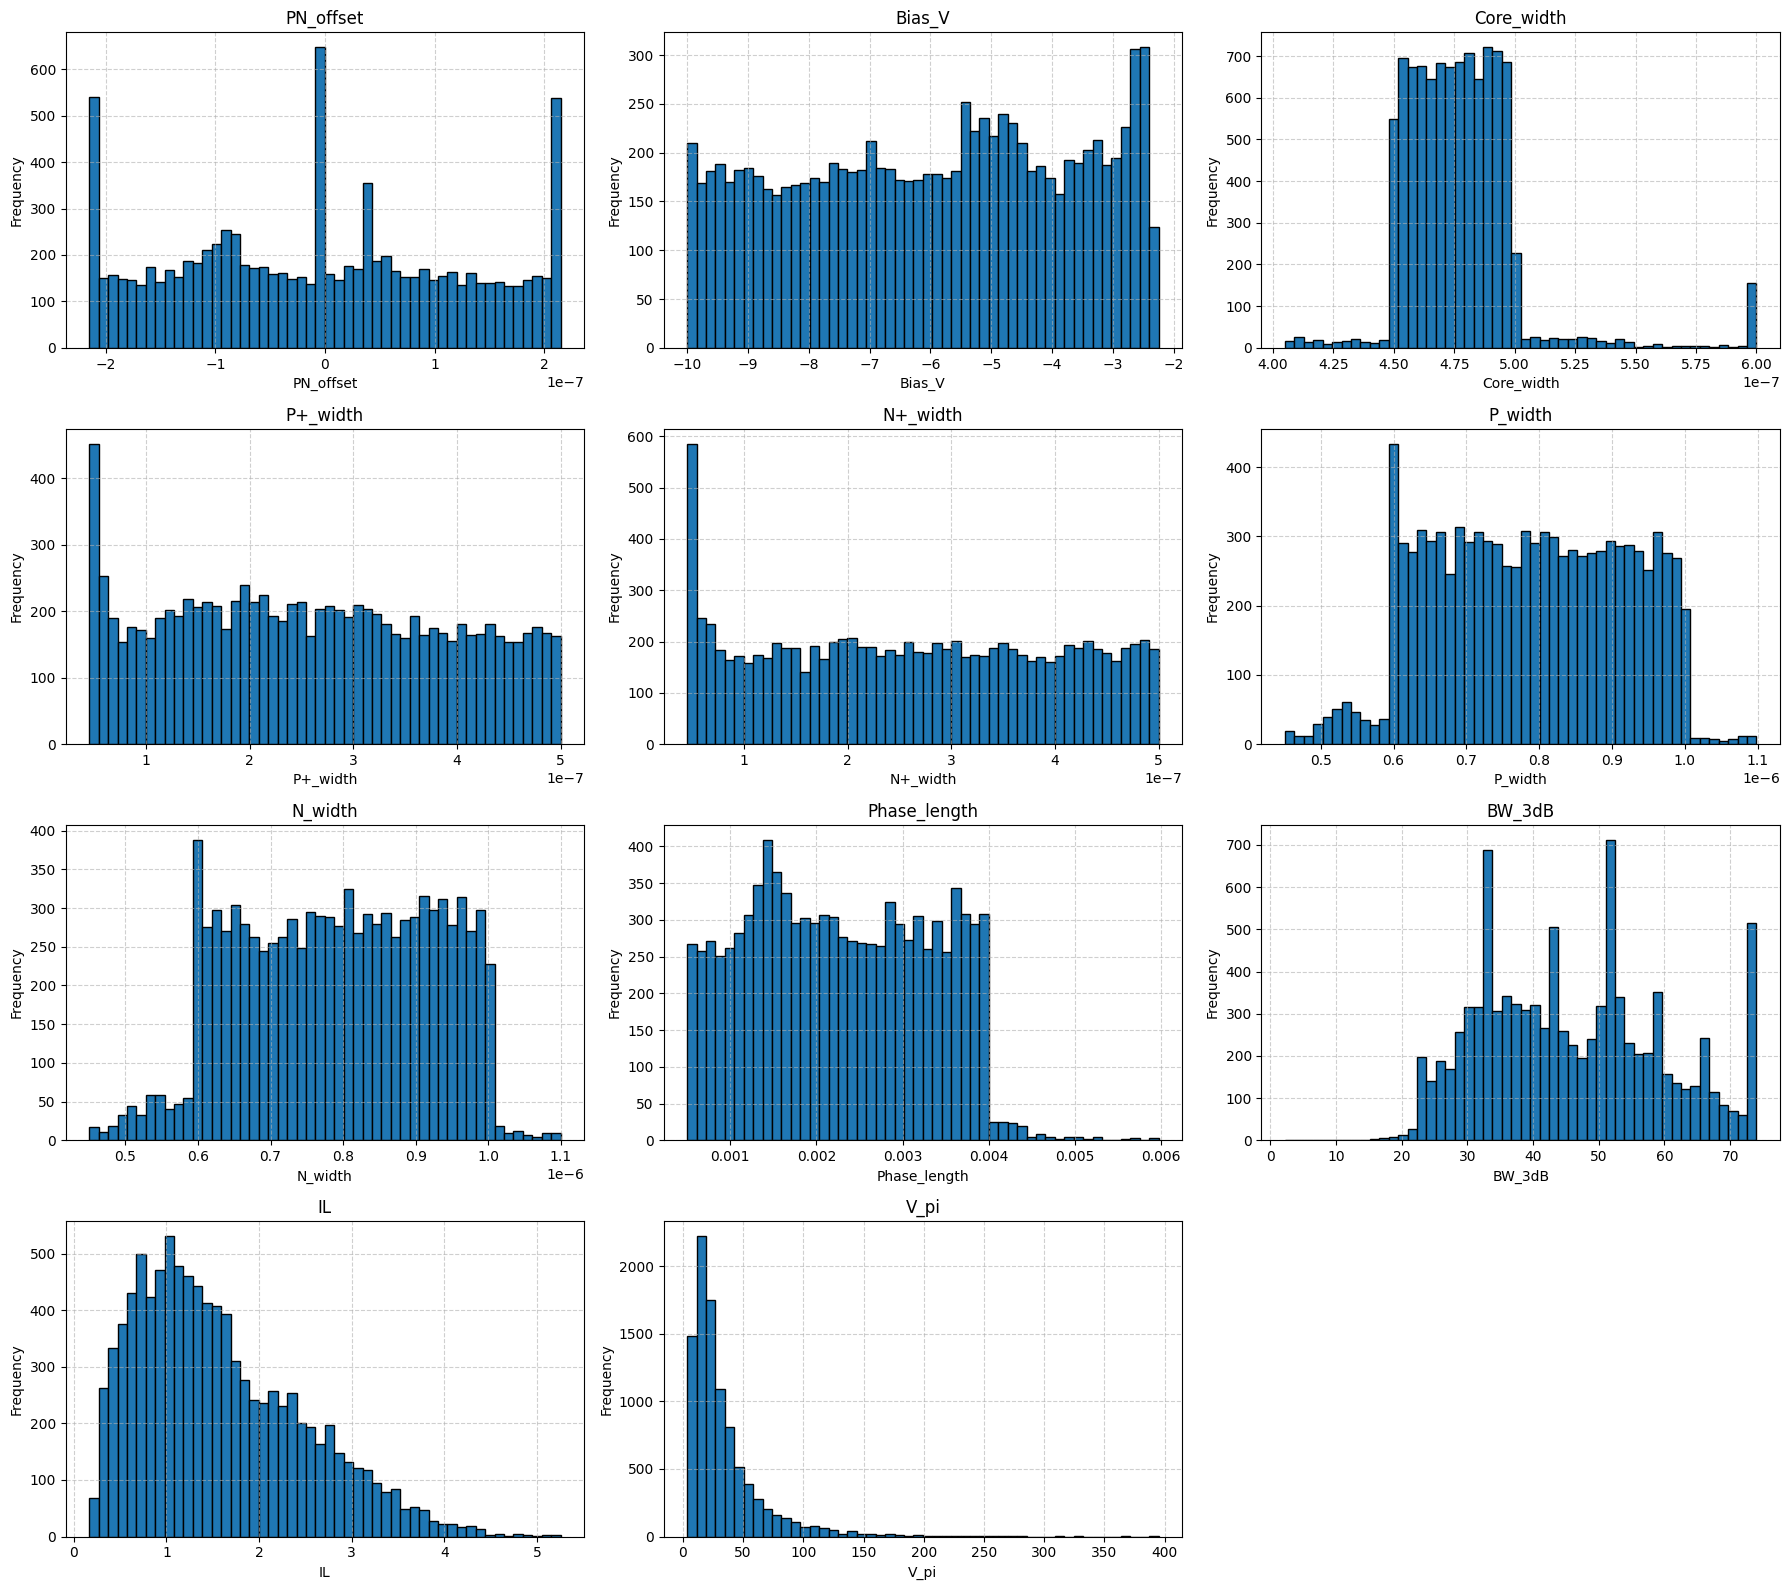

In [6]:
# Combine all columns
all_cols = list(feature_cols) + list(target_cols)
n_cols = len(all_cols)

# Define grid size
n_grid_cols = 3
n_grid_rows = 4

fig, axes = plt.subplots(
    nrows=n_grid_rows,
    ncols=n_grid_cols,
    figsize=(6 * n_grid_cols, 4 * n_grid_rows)
)

axes = axes.flatten()

for i, col in enumerate(all_cols):
    axes[i].hist(df_cleaned[col], bins=50, edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

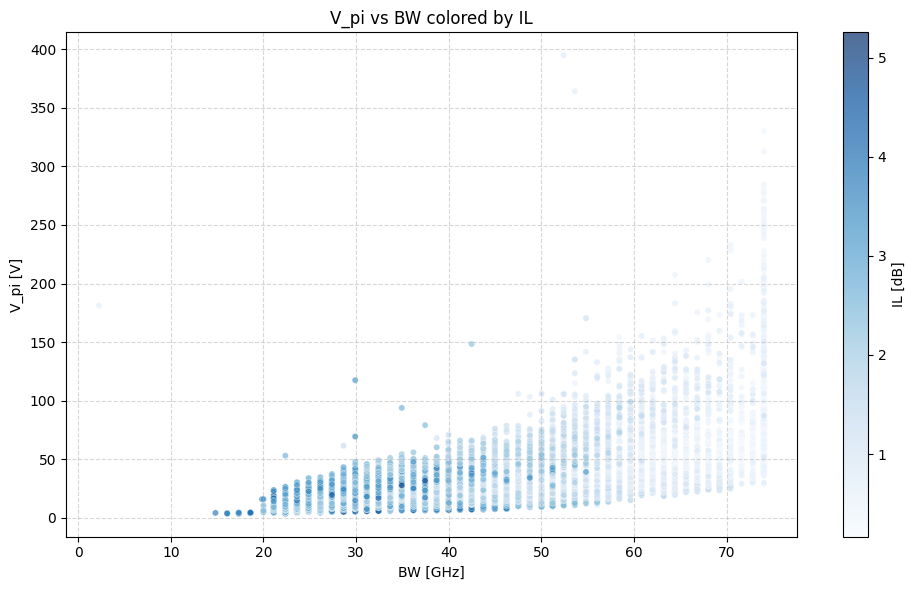

In [7]:
x = df_cleaned['BW_3dB']
y = df_cleaned['V_pi']
c = df_cleaned['IL']

plt.figure(figsize=(10,6))
sc = plt.scatter(x, y, c=c, cmap='Blues', alpha=0.7, s=20, edgecolors='w', linewidth=0.3)

plt.xlabel('BW [GHz]')
plt.ylabel('V_pi [V]')
plt.title('V_pi vs BW colored by IL')

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('IL [dB]')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

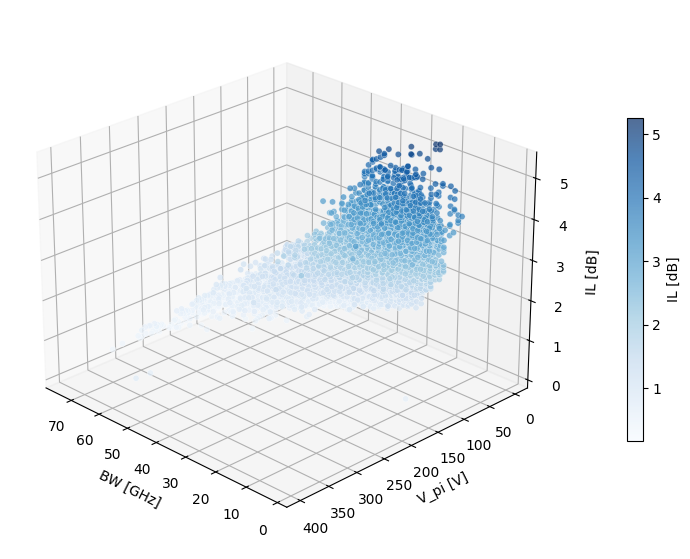

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter
sc = ax.scatter(x, y, c, c=c, cmap='Blues', s=20, alpha=0.7, edgecolors='w', linewidth=0.3)

# Axes labels
ax.set_xlabel('BW [GHz]')
ax.set_ylabel('V_pi [V]')
ax.set_zlabel('IL [dB]')

# Optional: colorbar to reinforce the color scale
cbar = plt.colorbar(sc, pad=0.1, shrink=0.6)
cbar.set_label('IL [dB]')

# Optional: view angle
ax.view_init(elev=25, azim=135)  # tweak as needed

plt.show()

## GPU Setup

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

x_train_t = x_train_t.to(device)
y_train_t = y_train_t.to(device)
x_test_t  = x_test_t.to(device)
y_test_t  = y_test_t.to(device)

Using device: cuda


## Training Function
A self-contained training function that accepts all hyperparameters and returns the final train/test losses.

In [10]:
def train_model(
    lambda_bw_mon,
    lambda_IL_mon,
    lambda_vpiL,
    lambda_smooth,
    # Fixed hyperparameters (change below if needed)
    D_i=8,
    D_o=3,
    dropout_rate=0.2,
    batch_size=128,
    learning_rate=1e-3,
    weight_decay=0.05,
    betas=(0.9, 0.999),
    n_epoch=100,
    verbose=False,
    trial=None,  # Optuna trial for pruning
):
    """
    Build, train and evaluate a MLP-PINN model with the given hyperparameters.

    Returns
    -------
    dict with keys:
        'train_loss', 'test_loss',
        'train_history', 'test_history',
        'model_state'
    """
    # --- Build model ---
    model = MLP5(input_dim=D_i, output_dim=D_o, dropout=dropout_rate).to(device)

    n_params = sum(p.numel() for p in model.parameters())

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate,
        weight_decay=weight_decay, betas=betas,
    )
    loss_function = nn.MSELoss()

    data_loader = DataLoader(
        TensorDataset(x_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True,
    )

    train_hist = np.zeros(n_epoch)
    test_hist  = np.zeros(n_epoch)

    # --- Training loop ---
    for epoch in range(n_epoch):
        model.train()
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            x_batch.requires_grad_(True)

            optimizer.zero_grad()
            pred = model(x_batch)
            data_loss = loss_function(pred, y_batch)

            BW_pred  = pred[:, 0]
            IL_pred  = pred[:, 1]
            Vpi_pred = pred[:, 2]
            L_batch  = x_batch[:, 7]

            physics_loss = 0.0

            # 1) dBW/dL <= 0
            if lambda_bw_mon != 0:
                grads = torch.autograd.grad(
                    BW_pred, x_batch,
                    grad_outputs=torch.ones_like(BW_pred),
                    create_graph=True,
                )[0]
                dBW_dL = grads[:, 7]
                physics_loss += lambda_bw_mon * torch.mean(torch.relu(dBW_dL) ** 2)

            # 2) dIL/dL >= 0
            if lambda_IL_mon != 0:
                grads = torch.autograd.grad(
                    IL_pred, x_batch,
                    grad_outputs=torch.ones_like(IL_pred),
                    create_graph=True,
                )[0]
                dIL_dL = grads[:, 7]
                physics_loss += lambda_IL_mon * torch.mean(torch.relu(-dIL_dL) ** 2)

            # 3) d(Vpi*L)/dL ≈ 0
            if lambda_vpiL != 0:
                VpiL = Vpi_pred * L_batch
                grads = torch.autograd.grad(
                    VpiL, x_batch,
                    grad_outputs=torch.ones_like(VpiL),
                    create_graph=True,
                )[0]
                dVpiL_dL = grads[:, 7]
                physics_loss += lambda_vpiL * torch.mean(dVpiL_dL ** 2)

            # 4) Smoothness (|d²BW/dL²|)
            if lambda_smooth != 0:
                grads1 = torch.autograd.grad(
                    BW_pred, x_batch,
                    grad_outputs=torch.ones_like(BW_pred),
                    create_graph=True,
                )[0]
                dBW_dL = grads1[:, 7]
                grads2 = torch.autograd.grad(
                    dBW_dL, x_batch,
                    grad_outputs=torch.ones_like(dBW_dL),
                    create_graph=True,
                )[0]
                d2BW_dL2 = grads2[:, 7]
                physics_loss += lambda_smooth * torch.mean(d2BW_dL2 ** 2)

            loss = data_loss + physics_loss
            loss.backward()
            optimizer.step()

        # --- Evaluation ---
        model.eval()
        with torch.no_grad():
            train_loss = loss_function(model(x_train_t), y_train_t).item()
            test_loss  = loss_function(model(x_test_t), y_test_t).item()
            train_hist[epoch] = train_loss
            test_hist[epoch]  = test_loss

        if verbose and (epoch % 5 == 0):
            print(f"  Epoch {epoch:4d} | Train {train_loss:.6f} | Test {test_loss:.6f}")

        # Optuna pruning
        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return {
        'train_loss': train_hist[-1],
        'test_loss':  test_hist[-1],
        'train_history': train_hist,
        'test_history':  test_hist,
        'model_state': deepcopy(model.state_dict()),
        'n_params': n_params,
    }

## Hyperparameter Search Configuration

Define the search space for all tuned hyperparameters.

In [11]:
# ==============================
# Search Space Definition
# ==============================

# Number of Optuna trials
N_OPTUNA_TRIALS = 100

# Training epochs per trial (lower for faster search; retrain best with more)
SEARCH_EPOCHS = 40

# Final retraining epochs for the best config
FINAL_EPOCHS = 400

## Optuna Search
Uses TPE sampler and median pruner.

In [12]:
def objective(trial):
    # --- Sample hyperparameters ---
    lambda_bw_mon = trial.suggest_float("lambda_bw_mon", 0.75, 0.95)
    lambda_IL_mon = trial.suggest_float("lambda_IL_mon", 0.25, 0.4)
    lambda_vpiL   = 0.005
    lambda_smooth  = 0.1

    result = train_model(
        lambda_bw_mon=lambda_bw_mon,
        lambda_IL_mon=lambda_IL_mon,
        lambda_vpiL=lambda_vpiL,
        lambda_smooth=lambda_smooth,
        n_epoch=SEARCH_EPOCHS,
        verbose=False,
        trial=trial,
    )
    return result['test_loss']

In [13]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=random_state),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=20),
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

# --- Best trial summary ---
best = study.best_trial
print("\n" + "="*50)
print(f"Best test loss: {best.value:.6f}")
print("Best hyperparameters:")
for k, v in best.params.items():
    if k == "hidden_dims_idx":
        print(f"  hidden_dims = {HIDDEN_DIM_OPTIONS[v]}")
    else:
        print(f"  {k} = {v}")
print("="*50)

[I 2026-03-11 05:20:18,238] A new study created in memory with name: no-name-8ebb7fb6-9d1b-4a4b-a3b2-9ff46b65fb07
  0%|                                                                                                                                                                  | 0/100 [00:11<?, ?it/s]


[W 2026-03-11 05:20:29,207] Trial 0 failed with parameters: {'lambda_bw_mon': 0.8892938371195723, 'lambda_IL_mon': 0.2929209002425569} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/salastro/Documents/Research/MZM/code/venv/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_28108/2501968446.py", line 8, in objective
    result = train_model(
        lambda_bw_mon=lambda_bw_mon,
    ...<5 lines>...
        trial=trial,
    )
  File "/tmp/ipykernel_28108/2107157682.py", line 115, in train_model
    loss.backward()
    ~~~~~~~~~~~~~^^
  File "/home/salastro/Documents/Research/MZM/code/venv/lib/python3.14/site-packages/torch/_tensor.py", line 630, in backward
    torch.autograd.backward(
    ~~~~~~~~~~~~~~~~~~~~~~~^
        self, gradient, retain_graph, create_graph, inputs=inputs
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    

KeyboardInterrupt: 

## Results Analysis & Visualization

In [ ]:
# # ==============================
# # Collect best hyperparameters
# # ==============================
# bp = study.best_trial.params
# best_config = {
#     'lambda_bw_mon': bp['lambda_bw_mon'],
#     'lambda_IL_mon': bp['lambda_IL_mon'],
#     'lambda_vpiL':   0.005,
#     'lambda_smooth': 0.1,
# }

In [14]:
best_config = {
    'lambda_bw_mon': 0.0,
    'lambda_IL_mon': 0.3,
    'lambda_vpiL':   0.005,
    'lambda_smooth': 0.1,
}


In [ ]:
# ==============================
# Optuna Visualizations
# ==============================
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
)

fig = plot_optimization_history(study)
plt.title("Optimization History")
plt.tight_layout()
plt.show()

fig = plot_param_importances(study)
plt.tight_layout()
plt.show()

fig = plot_parallel_coordinate(study)
plt.title("Parallel Coordinate Plot")
plt.tight_layout()
plt.show()

fig = plot_slice(study)
# plt.tight_layout()
plt.show()

## Retrain Best Model (Full Epochs)
Retrain the best configuration with more epochs and verbose logging.

In [15]:
print(f"Retraining best config for {FINAL_EPOCHS} epochs ...\n")

final_result = train_model(
    lambda_bw_mon=best_config['lambda_bw_mon'],
    lambda_IL_mon=best_config['lambda_IL_mon'],
    lambda_vpiL=best_config['lambda_vpiL'],
    lambda_smooth=best_config['lambda_smooth'],
    n_epoch=FINAL_EPOCHS,
    verbose=True,
)

print(f"\nFinal Train Loss: {final_result['train_loss']:.6f}")
print(f"Final Test  Loss: {final_result['test_loss']:.6f}")
print(f"Model parameters: {final_result['n_params']}")

Retraining best config for 400 epochs ...

  Epoch    0 | Train 0.147125 | Test 0.142773
  Epoch    5 | Train 0.052360 | Test 0.047388
  Epoch   10 | Train 0.040624 | Test 0.035731
  Epoch   15 | Train 0.048976 | Test 0.048242
  Epoch   20 | Train 0.034710 | Test 0.032566
  Epoch   25 | Train 0.034637 | Test 0.033306
  Epoch   30 | Train 0.030092 | Test 0.027886
  Epoch   35 | Train 0.034515 | Test 0.031291
  Epoch   40 | Train 0.033648 | Test 0.031776
  Epoch   45 | Train 0.027584 | Test 0.027639
  Epoch   50 | Train 0.026064 | Test 0.025432
  Epoch   55 | Train 0.025362 | Test 0.022574
  Epoch   60 | Train 0.022605 | Test 0.018809
  Epoch   65 | Train 0.019610 | Test 0.016277
  Epoch   70 | Train 0.021787 | Test 0.018095
  Epoch   75 | Train 0.019932 | Test 0.017804
  Epoch   80 | Train 0.020696 | Test 0.018057
  Epoch   85 | Train 0.020930 | Test 0.018943
  Epoch   90 | Train 0.018716 | Test 0.016204
  Epoch   95 | Train 0.018246 | Test 0.015731
  Epoch  100 | Train 0.019248 | Test 

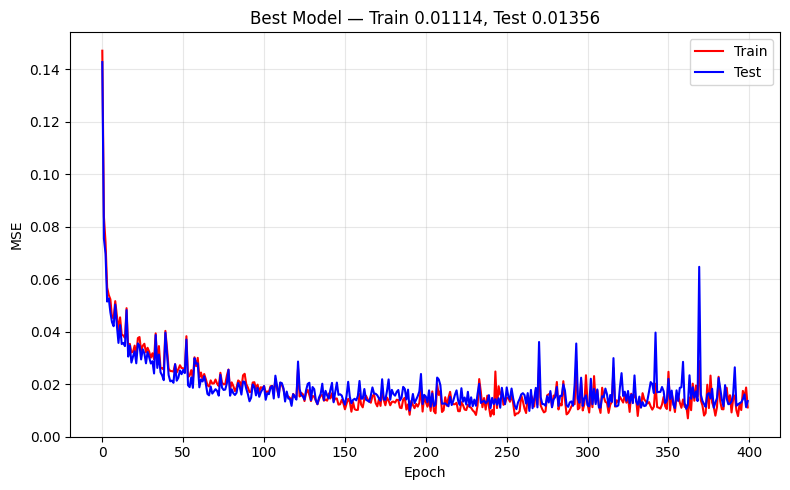

In [16]:
# ==============================
# Training Curves for Best Model
# ==============================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(final_result['train_history'], 'r-', label='Train')
ax.plot(final_result['test_history'],  'b-', label='Test')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title(
    f"Best Model — Train {final_result['train_loss']:.5f}, "
    f"Test {final_result['test_loss']:.5f}"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-Output Error Analysis

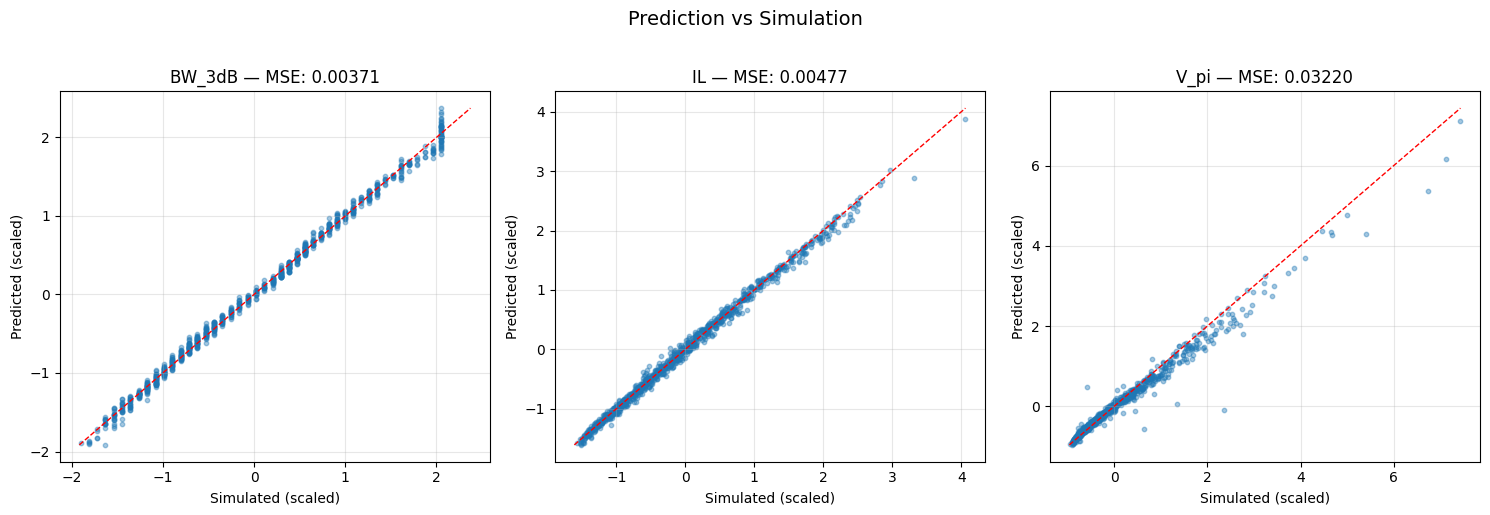

In [17]:
# ==============================
# Load best model and evaluate per-output
# ==============================
best_model = MLP5().to(device)
best_model.load_state_dict(final_result['model_state'])
best_model.eval()

with torch.no_grad():
    pred_test = best_model(x_test_t).cpu().numpy()

y_test_np = y_test_t.cpu().numpy()
target_names = ['BW_3dB', 'IL', 'V_pi']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (name, ax) in enumerate(zip(target_names, axes)):
    ax.scatter(y_test_np[:, i], pred_test[:, i], alpha=0.4, s=10)
    lims = [
        min(y_test_np[:, i].min(), pred_test[:, i].min()),
        max(y_test_np[:, i].max(), pred_test[:, i].max()),
    ]
    ax.plot(lims, lims, 'r--', lw=1)
    mse_i = np.mean((y_test_np[:, i] - pred_test[:, i])**2)
    ax.set_title(f"{name} — MSE: {mse_i:.5f}")
    ax.set_xlabel('Simulated (scaled)')
    ax.set_ylabel('Predicted (scaled)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Prediction vs Simulation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Save Best Configuration

In [18]:
# ==============================
# Save results
# ==============================
save_dict = {
    'best_config': {k: (v if not isinstance(v, list) else v)
                    for k, v in best_config.items()},
    'final_train_loss': float(final_result['train_loss']),
    'final_test_loss':  float(final_result['test_loss']),
    'n_params': final_result['n_params'],
}

with open('best_hyperparams.json', 'w') as f:
    json.dump(save_dict, f, indent=2)
print("Saved to best_hyperparams.json")

# Save model weights
torch.save(final_result['model_state'], 'best_model.pt')
print("Saved model weights to best_model.pt")

print("\nBest configuration summary:")
print(json.dumps(save_dict, indent=2))

Saved to best_hyperparams.json
Saved model weights to best_model.pt

Best configuration summary:
{
  "best_config": {
    "lambda_bw_mon": 0.0,
    "lambda_IL_mon": 0.3,
    "lambda_vpiL": 0.005,
    "lambda_smooth": 0.1
  },
  "final_train_loss": 0.011141298338770866,
  "final_test_loss": 0.013557782396674156,
  "n_params": 619503
}
